# Введение в регрессионный анализ: интенсив по Python

*Алла Тамбовцева*

## Семинар 6. Операции с датафреймами Pandas: практика

Загрузите данные из файла `enhanced_anxiety_dataset.csv` (источник – Kaggle, описание данных [здесь](https://www.kaggle.com/datasets/natezhang123/social-anxiety-dataset)) и сохраните их в датафрейм `df`.

In [1]:
import pandas as pd

In [ ]:
# если файл скачан
df = pd.read_csv("enhanced_anxiety_dataset.csv")

In [2]:
# если по ссылке
df = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyReg26/refs/heads/main/enhanced_anxiety_dataset.csv")

In [3]:
# у столбцов длинные названия – со скобками
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


Запустите ячейку с кодом ниже, чтобы получить более короткие и удобные названия столбцов.

In [4]:
# метод .rename() переименовывает строки или столбцы,
# в аргумент можно поставить словарь с парами «старое название - новое название»
# или функцию, которая описывает правило переименования,
# здесь функция принимает название x, разбивает его 
# по скобке, забирает все, что до нее и убирает лишние пробелы

df = df.rename(columns = lambda x: x.split("(")[0].strip())

In [5]:
# теперь лучше
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity,Caffeine Intake,Alcohol Consumption,Smoking,Family History of Anxiety,Stress Level,Heart Rate,Breathing Rate,Sweating Level,Dizziness,Medication,Therapy Sessions,Recent Major Life Event,Diet Quality,Anxiety Level
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


### Задача 0

Проверьте, есть ли в данных пропущенные значения – посчитайте количество пропусков в каждом столбце датафрейма `df`.

In [6]:
# пропусков нет
print(df.isna().sum())

Age                          0
Gender                       0
Occupation                   0
Sleep Hours                  0
Physical Activity            0
Caffeine Intake              0
Alcohol Consumption          0
Smoking                      0
Family History of Anxiety    0
Stress Level                 0
Heart Rate                   0
Breathing Rate               0
Sweating Level               0
Dizziness                    0
Medication                   0
Therapy Sessions             0
Recent Major Life Event      0
Diet Quality                 0
Anxiety Level                0
dtype: int64


### Задача 1

Добавьте в `df` столбец `PB Index` со значениями «индекса психологического неблагополучия», который вычисляется по формуле:

    0.4 * Stress Level + 0.6 * Anxiety Level
    
Отсортируйте строки по убыванию значений `PB Index`. Выведите строки с топ-5 респодентами по уровню психологического неблагополучия.

In [7]:
df["PB Index"] = 0.4 * df["Stress Level"] + 0.6 * df["Anxiety Level"]
df.sort_values("PB Index", ascending = False).head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity,Caffeine Intake,Alcohol Consumption,Smoking,Family History of Anxiety,Stress Level,Heart Rate,Breathing Rate,Sweating Level,Dizziness,Medication,Therapy Sessions,Recent Major Life Event,Diet Quality,Anxiety Level,PB Index
8617,40,Male,Athlete,4.4,1.1,322,11,Yes,Yes,10,97,23,5,Yes,No,4,Yes,3,10.0,10.0
1435,28,Male,Other,3.5,2.1,459,11,Yes,Yes,10,116,27,5,Yes,Yes,4,No,4,10.0,10.0
7334,29,Female,Lawyer,4.2,0.4,344,11,Yes,Yes,10,96,21,3,Yes,Yes,9,Yes,2,10.0,10.0
114,33,Female,Chef,4.5,1.2,426,5,Yes,Yes,10,103,25,5,Yes,No,7,Yes,1,10.0,10.0
2224,30,Other,Teacher,3.9,2.7,564,9,Yes,Yes,10,93,28,5,No,Yes,7,Yes,4,10.0,10.0


### Задача 2

Выведите описательные статистики для столбца `Age`. Выведите таблицу частот для столбца `Occupation`.

In [8]:
print(df["Age"].describe())

count    11000.000000
mean        40.241727
std         13.236140
min         18.000000
25%         29.000000
50%         40.000000
75%         51.000000
max         64.000000
Name: Age, dtype: float64


In [9]:
print(df["Occupation"].value_counts())

Occupation
Musician      892
Artist        888
Student       878
Nurse         861
Chef          858
Doctor        842
Other         840
Freelancer    838
Engineer      833
Scientist     832
Athlete       822
Lawyer        809
Teacher       807
Name: count, dtype: int64


### Задача 3

Сохраните в датафрейм `data` строки, соответствующие респондентам не старше 30 лет, которые являются студентами, преподавателями (`Student` или `Teacher`) или имеют профессию, которая является модой столбца `Occupation`.

In [10]:
data = df[(df["Age"] <= 30) & 
    df["Occupation"].isin(["Student", "Teacher", "Musician"])]
print(data.shape) # проверяем размерность

(736, 20)


### Задача 4

Добавьте в `data` столбец `Smoker` со значениями:

* 1, если респондент курит
* 0, если респондент не курит.

Используйте для этого столбец `Smoking`.

In [11]:
data["Smoker"] = (data["Smoking"] == "Yes").astype(int)

### Задача 5

Представьте, что вам необходимо сравнить долю курильщиков среди студентов и преподавателей. Сохраните в отдельные датафреймы соответствующие строки и вычислите долю курильщиков от общего числа студентов и общего числа преподавателей.

In [12]:
students = data[data["Occupation"] == "Student"]
teachers = data[data["Occupation"] == "Teacher"]
print(students.shape)
print(teachers.shape)

(256, 21)
(240, 21)


In [13]:
print(students["Smoker"].mean())
print(teachers["Smoker"].mean())

0.55859375
0.5416666666666666


### Задача 6

Используя датафреймы из задачи 5, вычислите средний уровень тревожности (`Anxiety Level`) у студентов и преподавателей.

In [14]:
print(students["Anxiety Level"].mean())
print(teachers["Anxiety Level"].mean())

3.95703125
3.783333333333333


### Задача 7

Используя датафреймы из задачи 5, постройте для продолжительности сна (`Sleep Hours`):

* гистограммы (одна для студентов, другая – для преподавателей)
* ящики с усами (один для студентов, другой – для преподавателей)

Подсказка: примените к столбцу методы `.hist()` и `.plot.box()`.

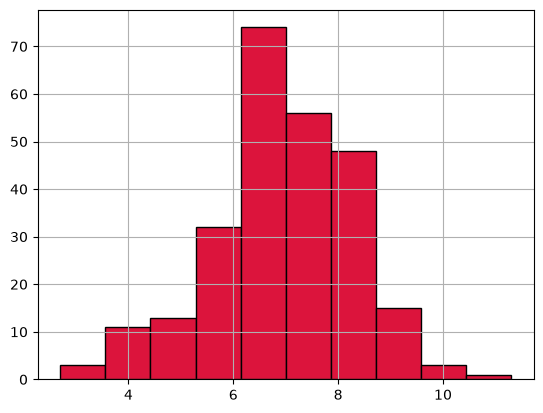

In [15]:
students["Sleep Hours"].hist(color = "crimson", edgecolor = "black");

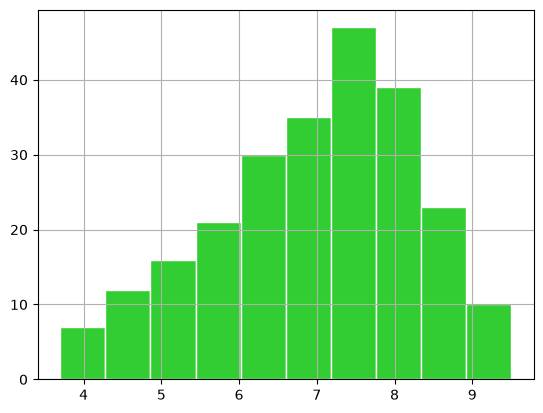

In [16]:
teachers["Sleep Hours"].hist(color = "limegreen", edgecolor = "white");

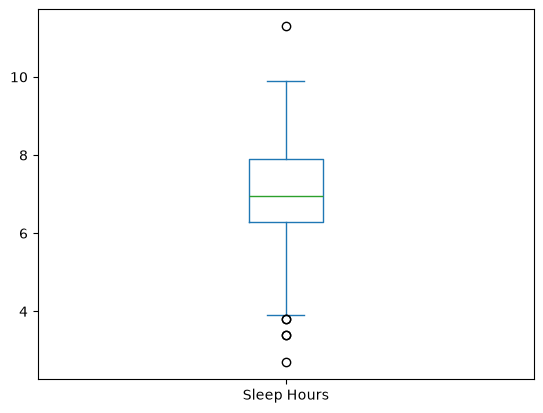

In [17]:
students["Sleep Hours"].plot.box();

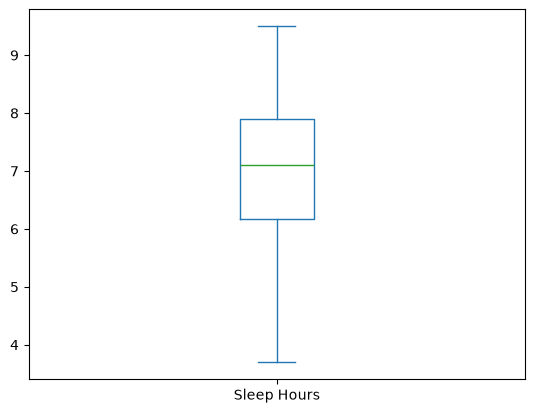

In [18]:
teachers["Sleep Hours"].plot.box();